# AMC a bajo SNR — Comparación de estrategias

Este notebook **no entrena nada** — carga los pesos ya entrenados en `../hos/`, `../stft/`,
`../wavelet/`, `../lstm_snr/` (las estrategias nuevas de esta carpeta) y, como referencia, 3
baselines de `../../Modelos iniciales/` (`cnn/`, `tcn/`, `cnn_preproc/` — este último es
`ULCNN`, la arquitectura más liviana del proyecto). La pregunta que responde: **¿alguna de
estas estrategias mejora la accuracy específicamente en el rango de bajo SNR (≤ -10 dB), donde
según `../README.md` los modelos "estándar" caen a precisión cercana al azar?**

Cada modelo se evalúa con la representación con la que fue entrenado (I/Q crudo, HOS, STFT o
wavelet).


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "../../Modelos iniciales")
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import CNNBaseline, TCN, ULCNN
from common.data import load_radioml_digital, split_dataset
from common.train import evaluate_by_snr, overall_accuracy, compute_cm

from common_snr.models import HOSClassifier, STFTCNN, CNNLSTMHybrid
from common_snr.features import compute_hos_features, compute_stft, compute_cwt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga del dataset (mismo split que en los notebooks de entrenamiento)

In [2]:
X, y, snrs, le = load_radioml_digital(dataset_folder="../../Modelos iniciales/rfml", seed=SEED)
N_CLASSES = len(le.classes_)

_, _, (X_test, y_test, snr_test) = split_dataset(X, y, snrs, seed=SEED)

# Cada modelo se evalúa con la representación con la que fue entrenado.
TEST_DATA = {
    "iq": X_test,
    "hos": compute_hos_features(X_test),
    "stft": compute_stft(X_test),
    "wavelet": compute_cwt(X_test),
}
print(f"Test: {X_test.shape}")

Test: (32000, 2, 128)


## 3. Carga de modelos ya entrenados

Igual que en `Modelos iniciales/comparacion/comparacion.ipynb`: se lee primero el `history.pkl`
de cada modelo para reconstruirlo con su `model_kwargs` exacto antes de cargar los pesos.

In [3]:
MODEL_SPECS = {
    # nombre: (clase, ruta de pesos, ruta de history, representación de entrada)
    "CNN (baseline)": (CNNBaseline, "../../Modelos iniciales/cnn/cnn.pt", "../../Modelos iniciales/cnn/history.pkl", "iq"),
    "TCN (baseline)": (TCN, "../../Modelos iniciales/tcn/tcn.pt", "../../Modelos iniciales/tcn/history.pkl", "iq"),
    "ULCNN (baseline)": (ULCNN, "../../Modelos iniciales/cnn_preproc/cnn_preproc.pt", "../../Modelos iniciales/cnn_preproc/history.pkl", "iq"),
    "HOS": (HOSClassifier, "../hos/hos.pt", "../hos/history.pkl", "hos"),
    "STFT-CNN": (STFTCNN, "../stft/stft.pt", "../stft/history.pkl", "stft"),
    "Wavelet-CNN": (STFTCNN, "../wavelet/wavelet.pt", "../wavelet/history.pkl", "wavelet"),
    "CNN+LSTM": (CNNLSTMHybrid, "../lstm_snr/lstm_snr.pt", "../lstm_snr/history.pkl", "iq"),
}

MODELOS = {}
histories = {}
representations = {}
for nombre, (model_cls, weight_path, history_path, representation) in MODEL_SPECS.items():
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    model_kwargs = history.get("model_kwargs", {})

    modelo = model_cls(n_classes=N_CLASSES, **model_kwargs)
    modelo.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    modelo.to(DEVICE)
    modelo.eval()

    MODELOS[nombre] = modelo
    histories[nombre] = history
    representations[nombre] = representation
    print(f"{nombre}: cargado con model_kwargs={model_kwargs}, representación={representation}")

CNN (baseline): cargado con model_kwargs={'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}, representación=iq
TCN (baseline): cargado con model_kwargs={'channels': 64, 'dilations': (1, 2, 4), 'dropout': 0.4}, representación=iq
ULCNN (baseline): cargado con model_kwargs={'n_cv': 16, 'kernel_size': 5, 'n_fmdr': 6, 'shuffle_groups': 2, 'attn_reduction': 2}, representación=iq
HOS: cargado con model_kwargs={'n_features': 16, 'hidden': (32, 16), 'dropout': 0.3}, representación=hos
STFT-CNN: cargado con model_kwargs={'channels': (16, 32), 'kernel_size': 3, 'fc_hidden': 64, 'dropout': 0.5}, representación=stft
Wavelet-CNN: cargado con model_kwargs={'channels': (16, 32), 'kernel_size': 3, 'fc_hidden': 64, 'dropout': 0.5}, representación=wavelet
CNN+LSTM: cargado con model_kwargs={'conv_channels': 32, 'kernel_size': 5, 'hidden_size': 64, 'num_layers': 1, 'fc_hidden': 64, 'dropout': 0.3}, representación=iq


## 4. Accuracy global, por debajo y por encima del límite de Fisher (-10 dB)

In [4]:
print("=== Resumen: accuracy global vs accuracy a muy bajo SNR ===")
print(f'{"Modelo":18s} | {"Parámetros":>12s} | {"Acc. global":>12s} | {"Acc. SNR<=-10":>14s}')
print("-" * 65)
resumen = {}
mask_muy_bajo = snr_test <= -10
for nombre, modelo in MODELOS.items():
    params = modelo.count_parameters()
    X_eval = TEST_DATA[representations[nombre]]
    acc = overall_accuracy(modelo, X_eval, y_test, DEVICE)
    acc_bajo = overall_accuracy(modelo, X_eval[mask_muy_bajo], y_test[mask_muy_bajo], DEVICE)
    resumen[nombre] = {"params": params, "acc": acc, "acc_bajo_snr": acc_bajo}
    print(f"{nombre:18s} | {params:12,d} | {acc:12.4f} | {acc_bajo:14.4f}")

=== Resumen: accuracy global vs accuracy a muy bajo SNR ===
Modelo             |   Parámetros |  Acc. global |  Acc. SNR<=-10
-----------------------------------------------------------------
CNN (baseline)     |    1,063,048 |       0.5134 |         0.1438
TCN (baseline)     |       75,592 |       0.5755 |         0.1440
ULCNN (baseline)   |        9,364 |       0.6158 |         0.1609
HOS                |        1,304 |       0.4420 |         0.1283
STFT-CNN           |        7,800 |       0.2309 |         0.1282
Wavelet-CNN        |        7,800 |       0.1765 |         0.1235
CNN+LSTM           |       30,312 |       0.5951 |         0.1640


## 5. Gráficos comparativos

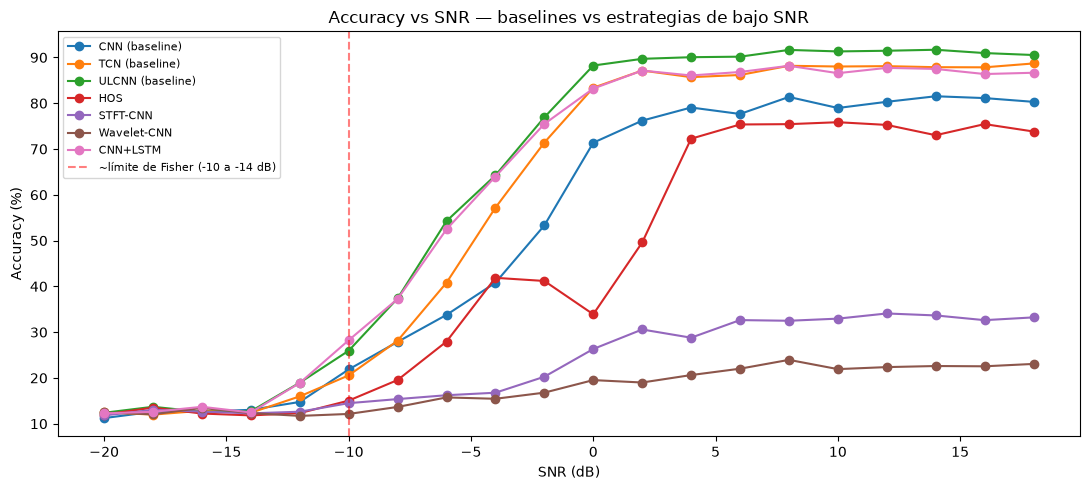

In [5]:
# Accuracy vs SNR — todos los modelos, con línea de referencia en -10 dB
plt.figure(figsize=(11, 5))
for nombre, modelo in MODELOS.items():
    X_eval = TEST_DATA[representations[nombre]]
    snr_acc = evaluate_by_snr(modelo, X_eval, y_test, snr_test, device=DEVICE)
    snr_levels = sorted(snr_acc.keys())
    plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o", label=nombre)

plt.axvline(-10, color="red", linestyle="--", alpha=0.5, label="~límite de Fisher (-10 a -14 dB)")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — baselines vs estrategias de bajo SNR")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_vs_snr_comparacion.png", dpi=150)
plt.show()

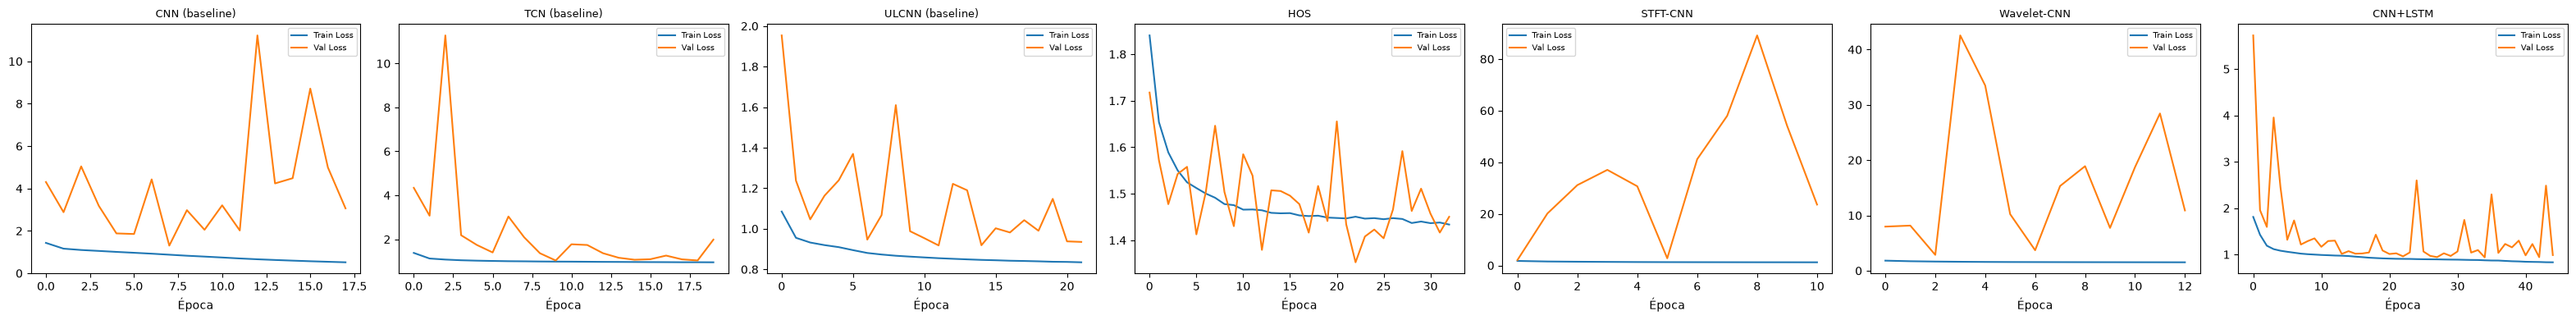

In [6]:
# Curvas de pérdida — todos los modelos
fig, axes = plt.subplots(1, len(MODELOS), figsize=(4.5 * len(MODELOS), 4))
for ax, nombre in zip(axes, MODELOS.keys()):
    history = histories[nombre]
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["val_loss"], label="Val Loss")
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel("Época")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("curvas_perdida.png", dpi=150)
plt.show()

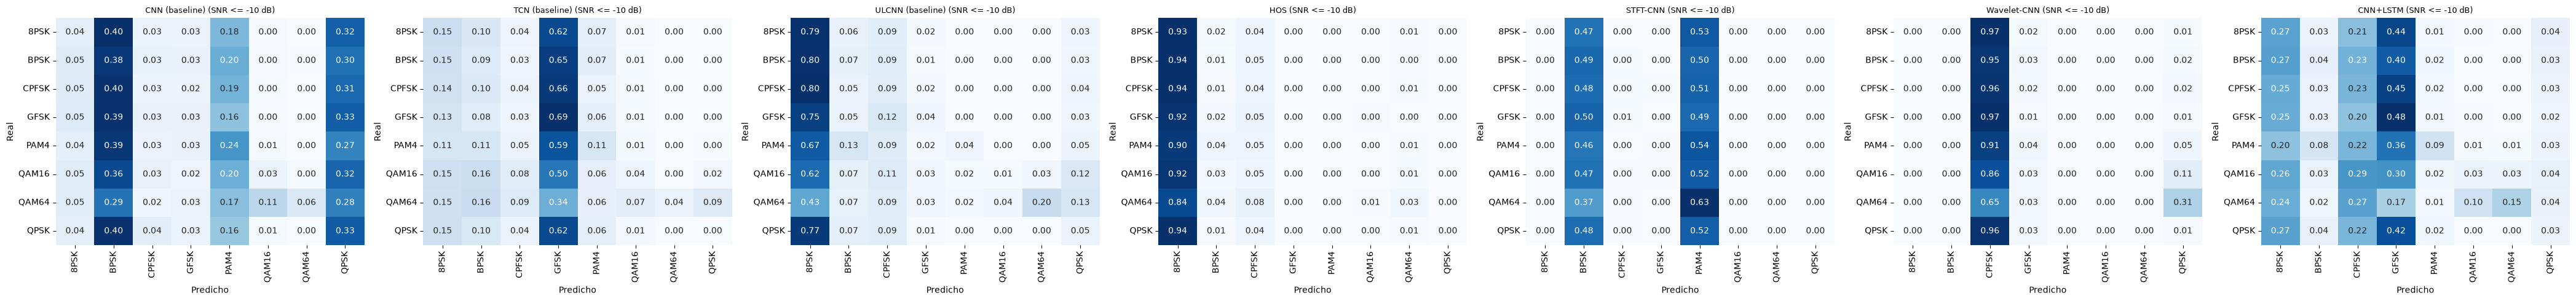

In [7]:
# Matrices de confusión — SOLO SNR <= -10 dB (el rango que nos interesa acá)
fig, axes = plt.subplots(1, len(MODELOS), figsize=(6 * len(MODELOS), 5))
for ax, nombre in zip(axes, MODELOS.keys()):
    modelo = MODELOS[nombre]
    X_eval = TEST_DATA[representations[nombre]]
    cm = compute_cm(modelo, X_eval[mask_muy_bajo], y_test[mask_muy_bajo], device=DEVICE)
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{nombre} (SNR <= -10 dB)", fontsize=9)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrices_muy_bajo_snr.png", dpi=150)
plt.show()

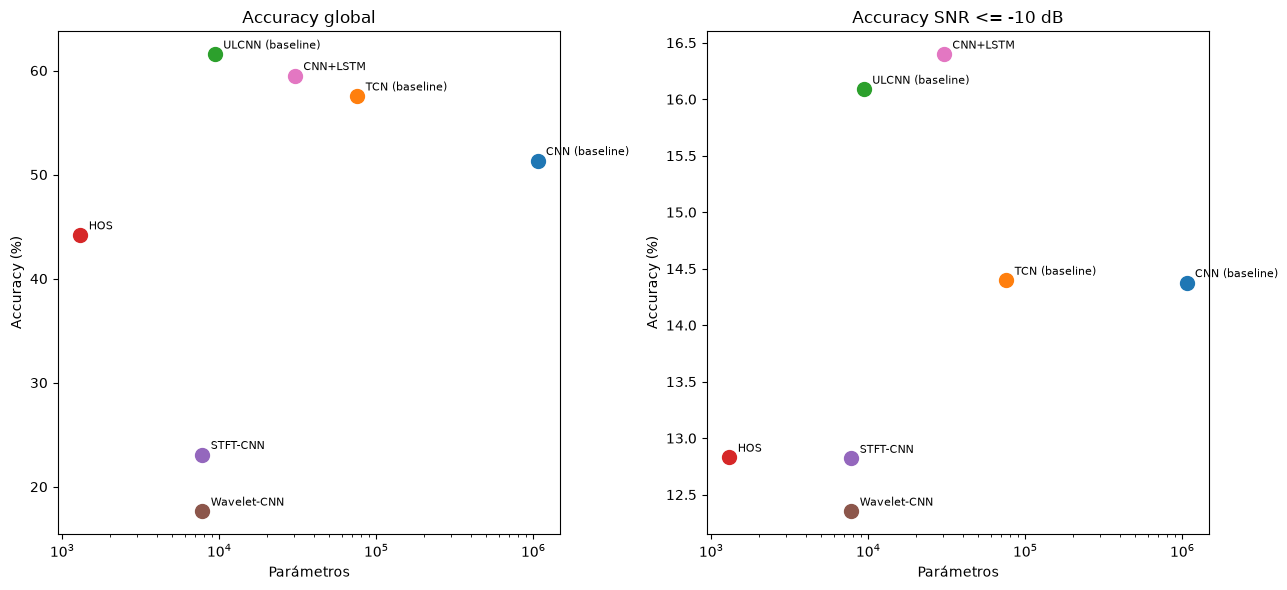

In [8]:
# Accuracy (global y a bajo SNR) vs parámetros — trade-off liviandad / desempeño
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, key, titulo in zip(axes, ["acc", "acc_bajo_snr"], ["Accuracy global", "Accuracy SNR <= -10 dB"]):
    for nombre, r in resumen.items():
        ax.scatter(r["params"], r[key] * 100, s=100)
        ax.annotate(nombre, (r["params"], r[key] * 100), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)
    ax.set_xlabel("Parámetros")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xscale("log")
    ax.set_title(titulo)
plt.tight_layout()
plt.savefig("accuracy_vs_parametros.png", dpi=150)
plt.show()